# Préparation des données Parcoursup

Ce bloc prépare une base propre avant l'analyse uni-dimensionnelle :
- chargement des données,
- sélection des variables utiles,
- création d'indicateurs simples et interprétables pour l'analyse.


In [2]:
getwd()
file.exists("data/raw/Parcoursup.csv")


[1] "/home/brandam/Bureau/4A/Analyse_de_données/Projet/An2DO_4A"

[1] TRUE

In [3]:
library(tidyverse)

# lecture du CSV Parcoursup (sep=';' car format français, check.names pour noms exploitables en R)
data <- read.csv('data/raw/Parcoursup.csv', sep = ';', header = TRUE, stringsAsFactors = TRUE, check.names = TRUE)

str(data)
utils::head(as.data.frame(data), 3)



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


'data.frame':	14252 obs. of  118 variables:
 $ Session                                                                                                                                         : int  2025 2025 2025 2025 2025 2025 2025 2025 2025 2025 ...
 $ Statut.de.l.établissement.de.la.filière.de.formation..public..privé..                                                                           : Factor w/ 4 levels "Privé enseignement supérieur",..: 4 4 4 4 4 4 4 4 4 4 ...
 $ Code.UAI.de.l.établissement                                                                                                                     : Factor w/ 4058 levels "0010006B","0010013J",..: 2576 3674 1395 2572 2572 1580 2990 3929 2933 3692 ...
 $ Établissement                                                                                                                                   : Factor w/ 3707 levels "3A, l’Ecole de management responsable et solidaire",..: 1197 3672 983 3546 3546 3565 3641 3652 349

,Session,Statut.de.l.établissement.de.la.filière.de.formation..public..privé..,Code.UAI.de.l.établissement,Établissement,Code.départemental.de.l.établissement,Département.de.l.établissement,Région.de.l.établissement,Académie.de.l.établissement,Commune.de.l.établissement,Filière.de.formation,⋯,tri,cod_aff_form,Concours.communs.et.banque.d.épreuves,Lien.de.la.formation.sur.la.plateforme.Parcoursup,Taux.d.accès,Part.des.terminales.générales.qui.étaient.en.position.de.recevoir.une.proposition.en.phase.principale,Part.des.terminales.technologiques.qui.étaient.en.position.de.recevoir.une.proposition.en.phase.principale,Part.des.terminales.professionnelles.qui.étaient.en.position.de.recevoir.une.proposition.en.phase.principale,etablissement_id_paysage,composante_id_paysage
,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,⋯,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<lgl>,<lgl>
1,2025,Public,0692185A,INSTITUT DES SCIENCES ET TECHNIQUES DE LA READAPTATION UNIVERSITE LYON 1,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 8e Arrondissement,Certificat de capacité d'Orthoptiste,⋯,3_Autres formations,28087,Aix-Marseille Université - Site de Marseille Timone,https://dossierappel.parcoursup.fr/Candidats/public/fiches/afficherFicheFormation?g_ta_cod=28087&typeBac=0&originePc=0,13,93,7,1,NA,NA
2,2025,Public,0931827F,Université Paris 8,93,Seine-Saint-Denis,Ile-de-France,Créteil,Saint-Denis,Licence - Langues étrangères appliquées - Parcours Anglais / Italien,⋯,1_universités,28100,,https://dossierappel.parcoursup.fr/Candidats/public/fiches/afficherFicheFormation?g_ta_cod=28100&typeBac=0&originePc=0,98,57,24,19,NA,NA
3,2025,Public,0421573G,IFSI du CH de Roanne,42,Loire,Auvergne-Rhône-Alpes,Lyon,Roanne,D.E Infirmier,⋯,3_Autres formations,28144,,https://dossierappel.parcoursup.fr/Candidats/public/fiches/afficherFicheFormation?g_ta_cod=28144&typeBac=0&originePc=0,40,56,37,7,NA,NA


## Vérification rapide

On vérifie la structure globale sans multiplier les diagnostics : dimensions, types et quelques statistiques de base.


In [4]:
# Vue d'ensemble des types de variables (numériques, caractères, etc.)
glimpse(data)

# Résumé ciblé sur des variables de volume utiles pour la suite
summary(select(data,
  Capacité.de.l.établissement.par.formation,
  Effectif.total.des.candidats.pour.une.formation,
  Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.
))


Rows: 14,252
Columns: 118
$ Session                                                                                                                                          <int> …
$ Statut.de.l.établissement.de.la.filière.de.formation..public..privé..                                                                            <fct> …
$ Code.UAI.de.l.établissement                                                                                                                      <fct> …
$ Établissement                                                                                                                                    <fct> …
$ Code.départemental.de.l.établissement                                                                                                            <fct> …
$ Département.de.l.établissement                                                                                                                   <fct> …
$ Région.de.l.établissement                 

 Capacité.de.l.établissement.par.formation
 Min.   :   0.00                          
 1st Qu.:  18.00                          
 Median :  30.00                          
 Mean   :  53.98                          
 3rd Qu.:  50.00                          
 Max.   :3400.00                          
 Effectif.total.des.candidats.pour.une.formation
 Min.   :    1.0                                
 1st Qu.:  160.0                                
 Median :  385.0                                
 Mean   :  947.4                                
 3rd Qu.: 1016.0                                
 Max.   :19404.0                                
 Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.
 Min.   :   0.00                                                                     
 1st Qu.:  14.00                                                                     
 Median :  25.00                                                                     
 Mean   :  4

## Nettoyage et variables construites

Logique du nettoyage :
- retirer les colonnes techniques ou trop fines pour l'objectif (identifiants, GPS, liens, détails redondants),
- conserver les colonnes utiles à l'analyse genre/sélectivité/profil des admis,
- construire des variables agrégées simples (2 phases, pourcentages de genre, parts de mentions).


In [5]:
# Colonnes retirées : identifiants techniques, géographie trop fine, détails redondants
cols_to_drop <- c(
  'Session',
  'Code.UAI.de.l.établissement',
  'Code.départemental.de.l.établissement',
  'Département.de.l.établissement',
  'Coordonnées.GPS.de.la.formation',
  'Commune.de.l.établissement',
  'Filière.de.formation.détaillée',
  'Filière.de.formation.détaillée.bis',
  'Filière.de.formation.très.détaillée',
  'Dont.effectif.des.candidats.ayant.postulé.en.internat',
  'Effectif.total.des.candidats.classés.par.l.établissement.en.phase.principale',
  'Effectif.des.candidats.classés.par.l.établissement.en.phase.complémentaire',
  'Effectif.des.candidats.classés.par.l.établissement.en.internat..CPGE.',
  'Effectif.des.candidats.classés.par.l.établissement.hors.internat..CPGE.',
  'Concours.communs.et.banque.d.épreuves',
  'cod_aff_form',
  'Lien.de.la.formation.sur.la.plateforme.Parcoursup',
  'etablissement_id_paysage',
  'composante_id_paysage'
)

# any_of : évite une erreur si une colonne listée est absente
data <- data %>%
  select(-any_of(cols_to_drop))

# Colonnes converties en numérique avant calcul de ratios
num_cols <- c(
  'Capacité.de.l.établissement.par.formation',
  'Effectif.total.des.candidats.en.phase.principale',
  'Effectif.total.des.candidats.en.phase.complémentaire',
  'Effectif.des.admis.en.phase.principale',
  'Effectif.des.admis.en.phase.complémentaire',
  'Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.',
  'Dont.effectif.des.candidates.admises',
  'Effectif.des.admis.néo.bacheliers',
  'Dont.effectif.des.admis.néo.bacheliers.sans.mention.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Assez.Bien.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Bien.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.avec.félicitations.au.bac'
)

data <- data %>%
  # across(...): applique as.numeric à toutes les colonnes de num_cols
  mutate(across(any_of(num_cols), ~ suppressWarnings(as.numeric(.x)))) %>%
  mutate(
    # Agrégation des volumes sur les deux phases d'admission
    Effectif.total.candidats.2phases = coalesce(Effectif.total.des.candidats.en.phase.principale, 0) +
      coalesce(Effectif.total.des.candidats.en.phase.complémentaire, 0),
    Effectif.total.admis.2phases = coalesce(Effectif.des.admis.en.phase.principale, 0) +
      coalesce(Effectif.des.admis.en.phase.complémentaire, 0),
      #coalesce remplace les valeurs manquantes par 0

    # Parts filles/garçons parmi les admis (entre 0 et 1)
    pct_filles_admises = if_else(
      Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis. > 0,
      Dont.effectif.des.candidates.admises / Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.,
      NA_real_
    ),
    pct_garcons_admis = if_else(!is.na(pct_filles_admises), 1 - pct_filles_admises, NA_real_),

    # Parts de mentions parmi les admis néo-bacheliers
    part_mention_ab = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Assez.Bien.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_),
    part_mention_b = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Bien.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_),
    part_mention_tb = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_),
    part_mention_tb_fel = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.avec.félicitations.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_)
  )


## Features principales pour l'analyse

On crée un jeu de features simple et cohérent avec le cours : ratios interprétables, transformations log des volumes et discrétisation par quantiles.


In [6]:
data <- data %>%
  rename(Statut.Etablissement = "Statut.de.l.établissement.de.la.filière.de.formation..public..privé..") 

data <- data %>%
  mutate(Statut.Etablissement = case_when(
    grepl("^Public", Statut.Etablissement) ~ "Public",
    grepl("^Privé",  Statut.Etablissement) ~ "Privé",
    TRUE ~ Statut.Etablissement  # garder les autres valeurs
  ))

data$Statut.Etablissement <- as.factor(data$Statut.Etablissement)

In [7]:
data <- data %>%
  mutate(
    # Total candidats et boursiers candidats (tous bacs confondus)
    total_candidats = Effectif.des.candidats.néo.bacheliers.généraux.en.phase.principale +
                      Effectif.des.candidats.néo.bacheliers.technologiques.en.phase.principale +
                      Effectif.des.candidats.néo.bacheliers.professionnels.en.phase.principale,
    
    total_boursiers_candidats = Dont.effectif.des.candidats.boursiers.néo.bacheliers.généraux.en.phase.principale +
                                Dont.effectif.des.candidats.boursiers.néo.bacheliers.technologiques.en.phase.principale +
                                Dont.effectif.des.candidats.boursiers.néo.bacheliers.professionnels.en.phase.principale,
    
    # Nouvelles features
    Pourcentage.boursiers.candidats = (total_boursiers_candidats / total_candidats) * 100,
    Pourcentage.boursiers.admis     = (Dont.effectif.des.admis.boursiers.néo.bacheliers / 
                                       Effectif.des.admis.néo.bacheliers) * 100
  ) %>%
  # Supprimer les colonnes intermédiaires
  select(-total_candidats, -total_boursiers_candidats)

In [8]:
glimpse(data)

Rows: 14,252
Columns: 109
$ Statut.Etablissement                                                                                                                             <fct> …
$ Établissement                                                                                                                                    <fct> …
$ Région.de.l.établissement                                                                                                                        <fct> …
$ Académie.de.l.établissement                                                                                                                      <fct> …
$ Filière.de.formation                                                                                                                             <fct> …
$ Sélectivité                                                                                                                                      <fct> …
$ Filière.de.formation.très.agrégée         

In [9]:
summary(data)

 Statut.Etablissement                                    Établissement  
 Privé : 3144         Université de Lille                       :  124  
 Public:11108         Université de Strasbourg                  :  103  
                      Sorbonne université                       :   98  
                      Université Paris Cité                     :   98  
                      Université Lyon 2 - Campus Porte des Alpes:   97  
                      Université Sorbonne Nouvelle Paris 3      :   92  
                      (Other)                                   :13640  
        Région.de.l.établissement Académie.de.l.établissement
 Ile-de-France       :2691        Paris     :1034            
 Auvergne-Rhône-Alpes:1730        Lille     : 960            
 Hauts-de-France     :1272        Versailles: 875            
 Occitanie           :1218        Nantes    : 840            
 Nouvelle Aquitaine  :1162        Lyon      : 832            
 Grand-Est           :1150        Créteil   

In [10]:
# Conversion de Taux.d.accès (texte) en proportion numérique [0,1]
data <- data %>%
  mutate(
    taux_acces_num = suppressWarnings(as.numeric(gsub(',', '.', gsub('%', '', Taux.d.accès)))) / 100
  )

data_features_core <- data %>%
  mutate(
    # Intensité de la demande vs places disponibles
    pression_candidature = if_else(Capacité.de.l.établissement.par.formation > 0,
      Effectif.total.candidats.2phases / Capacité.de.l.établissement.par.formation, NA_real_),

    # Probabilité d'être admis parmi les candidats
    taux_admission = if_else(Effectif.total.candidats.2phases > 0,
      Effectif.total.admis.2phases / Effectif.total.candidats.2phases, NA_real_),

    # Niveau de remplissage de la capacité
    taux_remplissage = if_else(Capacité.de.l.établissement.par.formation > 0,
      Effectif.total.admis.2phases / Capacité.de.l.établissement.par.formation, NA_real_),

    # Regroupement des meilleures mentions
    part_mention_haute = part_mention_tb + part_mention_tb_fel,

    # Score synthétique (pondération croissante avec le niveau de mention)
    score_mention = 1 * coalesce(part_mention_ab, 0) +
      2 * coalesce(part_mention_b, 0) +
      3 * coalesce(part_mention_tb, 0) +
      4 * coalesce(part_mention_tb_fel, 0),

    # log1p stabilise les variables de volume très asymétriques
    log_candidats = log1p(Effectif.total.candidats.2phases),
    log_admis = log1p(Effectif.total.admis.2phases),
    log_capacite = log1p(Capacité.de.l.établissement.par.formation),

    # Discrétisation en quartiles (1 = faible, 4 = élevé)
    pression_q = ntile(pression_candidature, 4),
    taux_acces_q = ntile(taux_acces_num, 4)
  ) %>%
  # Sélection du sous-ensemble de variables pour l'analyse
  select(
    Établissement, Statut.Etablissement, Filière.de.formation, Filière.de.formation.très.agrégée,
    Région.de.l.établissement, Académie.de.l.établissement, Sélectivité,Capacité.de.l.établissement.par.formation, Effectif.total.admis.2phases,Effectif.total.candidats.2phases,
    Pourcentage.boursiers.candidats,Pourcentage.boursiers.admis,
    pct_filles_admises, pct_garcons_admis,
    pression_candidature, taux_admission, taux_remplissage, taux_acces_num,
    part_mention_ab, part_mention_b, part_mention_tb, part_mention_tb_fel, part_mention_haute, score_mention,
    X..d.admis.néo.bacheliers.issus.de.la.même.académie..Paris.Créteil.Versailles.réunies.,
    X..d.admis.néo.bacheliers.généraux,
    X..d.admis.néo.bacheliers.technologiques,
    X..d.admis.néo.bacheliers.professionnels,
    log_candidats,
    log_admis,
    log_capacite
  )

# Vérification rapide du jeu de features final
glimpse(data_features_core)
summary(select(data_features_core, where(is.numeric)))


Rows: 14,252
Columns: 31
$ Établissement                                                                          <fct> …
$ Statut.Etablissement                                                                   <fct> …
$ Filière.de.formation                                                                   <fct> …
$ Filière.de.formation.très.agrégée                                                      <fct> …
$ Région.de.l.établissement                                                              <fct> …
$ Académie.de.l.établissement                                                            <fct> …
$ Sélectivité                                                                            <fct> …
$ Capacité.de.l.établissement.par.formation                                              <dbl> …
$ Effectif.total.admis.2phases                                                           <dbl> …
$ Effectif.total.candidats.2phases                                                       <dbl> …
$ Pou

 Capacité.de.l.établissement.par.formation Effectif.total.admis.2phases
 Min.   :   0.00                           Min.   :   0.00             
 1st Qu.:  18.00                           1st Qu.:  14.00             
 Median :  30.00                           Median :  25.00             
 Mean   :  53.98                           Mean   :  46.36             
 3rd Qu.:  50.00                           3rd Qu.:  46.00             
 Max.   :3400.00                           Max.   :2187.00             
                                                                       
 Effectif.total.candidats.2phases Pourcentage.boursiers.candidats
 Min.   :    1.0                  Min.   :  0.00                 
 1st Qu.:  160.0                  1st Qu.: 12.76                 
 Median :  385.0                  Median : 19.48                 
 Mean   :  947.4                  Mean   : 21.23                 
 3rd Qu.: 1016.0                  3rd Qu.: 27.72                 
 Max.   :19404.0            

In [11]:
#gestions des NA's : remplacement par la médiane
data_features_core <- data_features_core %>%
  mutate(across(where(is.numeric), 
                ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))

In [12]:
glimpse(data_features_core)
glimpse(select(data_features_core, where(is.numeric)))


Rows: 14,252
Columns: 31
$ Établissement                                                                          <fct> …
$ Statut.Etablissement                                                                   <fct> …
$ Filière.de.formation                                                                   <fct> …
$ Filière.de.formation.très.agrégée                                                      <fct> …
$ Région.de.l.établissement                                                              <fct> …
$ Académie.de.l.établissement                                                            <fct> …
$ Sélectivité                                                                            <fct> …
$ Capacité.de.l.établissement.par.formation                                              <dbl> …
$ Effectif.total.admis.2phases                                                           <dbl> …
$ Effectif.total.candidats.2phases                                                       <dbl> …
$ Pou

Rows: 14,252
Columns: 24
$ Capacité.de.l.établissement.par.formation                                              <dbl> …
$ Effectif.total.admis.2phases                                                           <dbl> …
$ Effectif.total.candidats.2phases                                                       <dbl> …
$ Pourcentage.boursiers.candidats                                                        <dbl> …
$ Pourcentage.boursiers.admis                                                            <dbl> …
$ pct_filles_admises                                                                     <dbl> …
$ pct_garcons_admis                                                                      <dbl> …
$ pression_candidature                                                                   <dbl> …
$ taux_admission                                                                         <dbl> …
$ taux_remplissage                                                                       <dbl> …
$ tau

In [13]:
#séparation des var quali et quanti
var_quanti <- names(data_features_core)[sapply(data_features_core, is.numeric)]
var_quali  <- names(data_features_core)[sapply(data_features_core, is.factor)]

# Vérifier
var_quanti
var_quali

[1] "Capacité.de.l.établissement.par.formation"                                             
 [2] "Effectif.total.admis.2phases"                                                          
 [3] "Effectif.total.candidats.2phases"                                                      
 [4] "Pourcentage.boursiers.candidats"                                                       
 [5] "Pourcentage.boursiers.admis"                                                           
 [6] "pct_filles_admises"                                                                    
 [7] "pct_garcons_admis"                                                                     
 [8] "pression_candidature"                                                                  
 [9] "taux_admission"                                                                        
[10] "taux_remplissage"                                                                      
[11] "taux_acces_num"                                                                        
[12] "part_mention_ab"                                                                       
[13] "part_mention_b"                                                                        
[14] "part_mention_tb"                                                                       
[15] "part_mention_tb_fel"                                                                   
[16] "part_mention_haute"                                                                    
[17] "score_mention"                                                                         
[18] "X..d.admis.néo.bacheliers.issus.de.la.même.académie..Paris.Créteil.Versailles.réunies."
[19] "X..d.admis.néo.bacheliers.généraux"                                                    
[20] "X..d.admis.néo.bacheliers.technologiques"                                              
[21] "X..d.admis.néo.bacheliers.professionnels"                                              
[22] "log_candidats"                                                                         
[23] "log_admis"                                                                             
[24] "log_capacite"

[1] "Établissement"                     "Statut.Etablissement"             
[3] "Filière.de.formation"              "Filière.de.formation.très.agrégée"
[5] "Région.de.l.établissement"         "Académie.de.l.établissement"      
[7] "Sélectivité"

# Analyse uni-dimensionnelle des variables

Autre formation               BTS               BUT              CPGE 
             1815              5351               820               986 
Ecole d'Ingénieur Ecole de Commerce              EFTS              IFSI 
              585               256               243               344 
          Licence       Licence_Las              PASS 
             3052               513               287

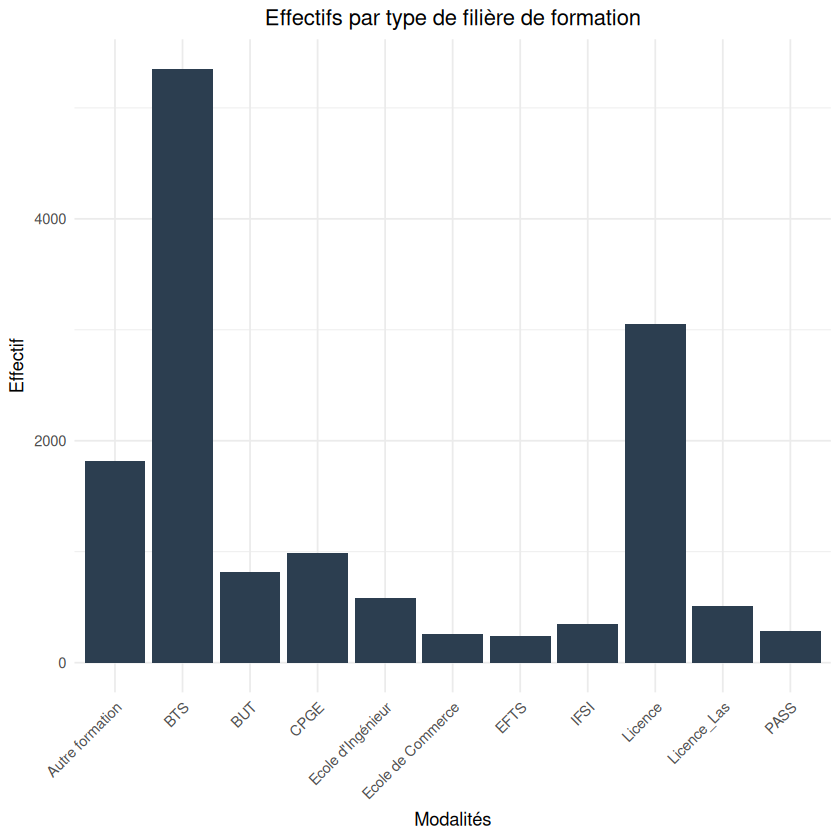

In [10]:
###Effectif par formation
summary(data_features_core$`Filière.de.formation.très.agrégée`)
library(ggplot2)

ggplot(data_features_core, aes(x = `Filière.de.formation.très.agrégée`)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par type de filière de formation",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

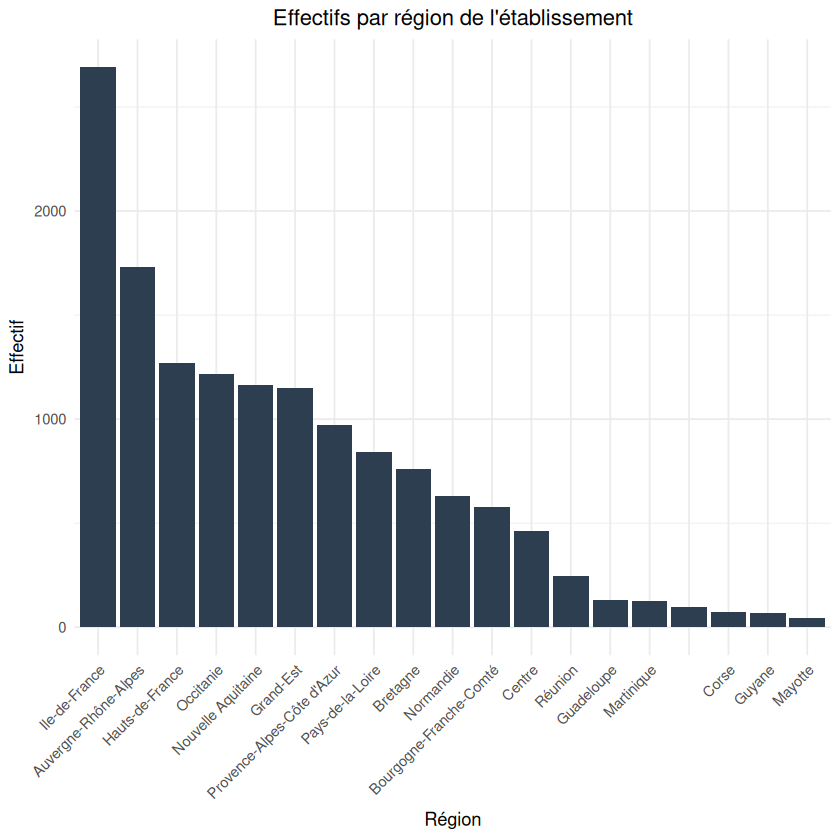

In [16]:
# Effectifs par région
data_features_core %>%
  count(Région.de.l.établissement) %>%
  ggplot(aes(x = reorder(Région.de.l.établissement, -n), y = n)) +
  geom_bar(stat = "identity", fill = "#2C3E50") +
  labs(
    title = "Effectifs par région de l'établissement",
    x = "Région",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

# Analyse pluri-dimensionnelle des variables

In [14]:
library(corrplot)

# Sélectionne les variables numériques pour l'étude
# (On utilise les noms issus du script de nettoyage)
cols_etude <- var_quanti

#Calcule la matrice de corrélation
# On utilise use = "complete.obs" pour ignorer les lignes avec des NA
matrice_corr <- cor(data_features_core%>% select(all_of(cols_etude)), use = "complete.obs")

# Affiche la matrice dans la console
print(round(matrice_corr, 2))
par(mar = c(1, 1, 1, 1))  # réduire les marges

png("corrplot.png", width = 2000, height = 2000, res = 150)
# 4. Visualisation graphique (Heatmap)
corrplot(matrice_corr, 
         method = "color",       
         type = "upper",         
         order = "original",       
         addCoef.col = "black",  
         tl.col = "black",
         tl.cex=0.5,
         number.cex = 0.5,       
         diag = FALSE            
)
dev.off()

                                                                                       Capacité.de.l.établissement.par.formation
Capacité.de.l.établissement.par.formation                                                                                   1.00
Effectif.total.admis.2phases                                                                                                0.78
Effectif.total.candidats.2phases                                                                                            0.42
Pourcentage.boursiers.candidats                                                                                            -0.05
Pourcentage.boursiers.admis                                                                                                -0.03
pct_filles_admises                                                                                                          0.10
pct_garcons_admis                                                                                

agg_record_1293295457 
                    2

Remarques: 
Pas un lien important entre mention et pression candidature  
la pression candidature est en revanche liée au taux accès 

`geom_smooth()` using formula = 'y ~ x'


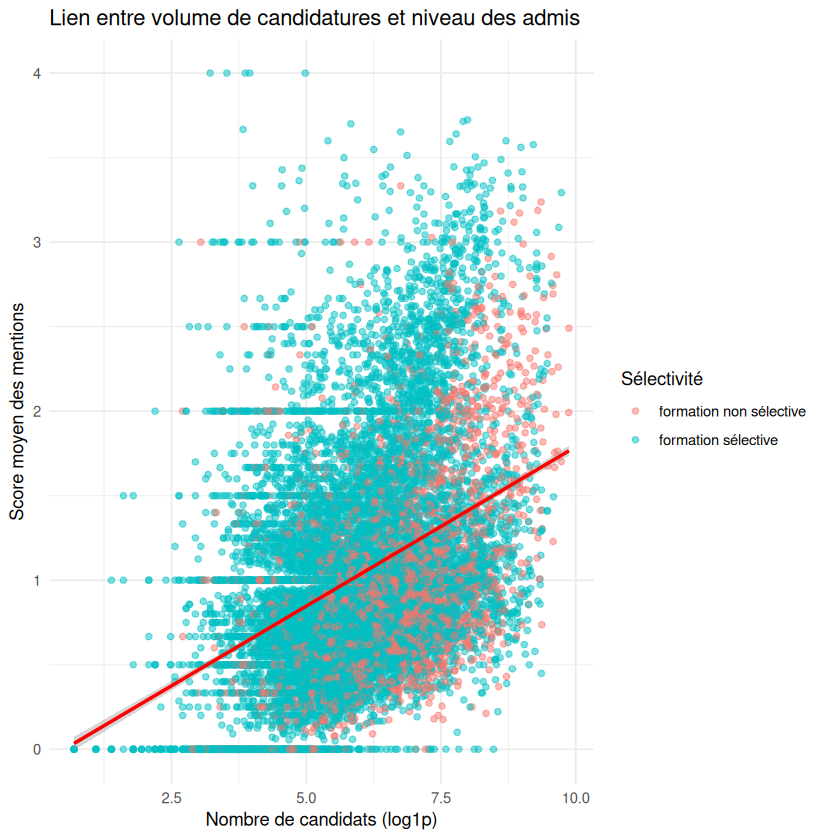

In [15]:
###Corrélation : Pression vs Niveau académique (Score Mention)

ggplot(data_features_core, aes(x = log_candidats, y = score_mention)) +
  geom_point(aes(color = Sélectivité), alpha = 0.5) +
  geom_smooth(method = "lm", color = "red") +
  labs(
    title = "Lien entre volume de candidatures et niveau des admis",
    x = "Nombre de candidats (log1p)",
    y = "Score moyen des mentions"
  ) +
  theme_minimal()

Plus il y a de candidats pour une formation plus leurs notes sont élevée en moyenne  (droite de régression rouge)
entre mentions 3 et 4 (bien/très bien) seulement des formations sélectives semblent être demandées

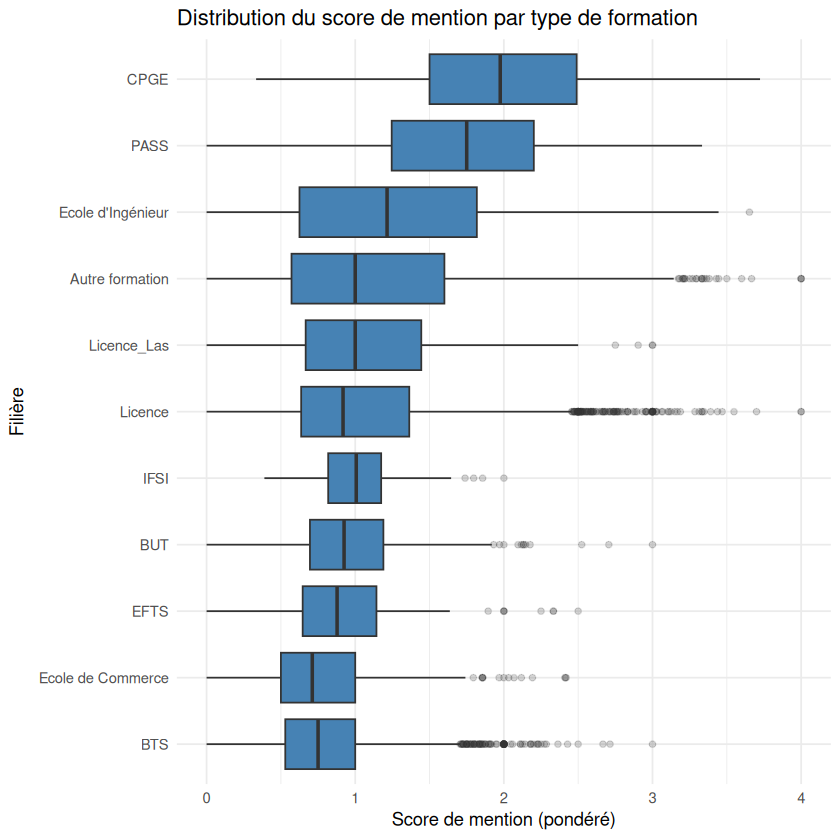

In [16]:
#Niveau admis par fillières
ggplot(data_features_core, aes(x = reorder(Filière.de.formation.très.agrégée, score_mention), y = score_mention)) +
  geom_boxplot(fill = "steelblue", outlier.alpha = 0.2) +
  coord_flip() + # Pour lire les noms des filières horizontalement
  labs(
    title = "Distribution du score de mention par type de formation",
    x = "Filière",
    y = "Score de mention (pondéré)"
  ) +
  theme_minimal()

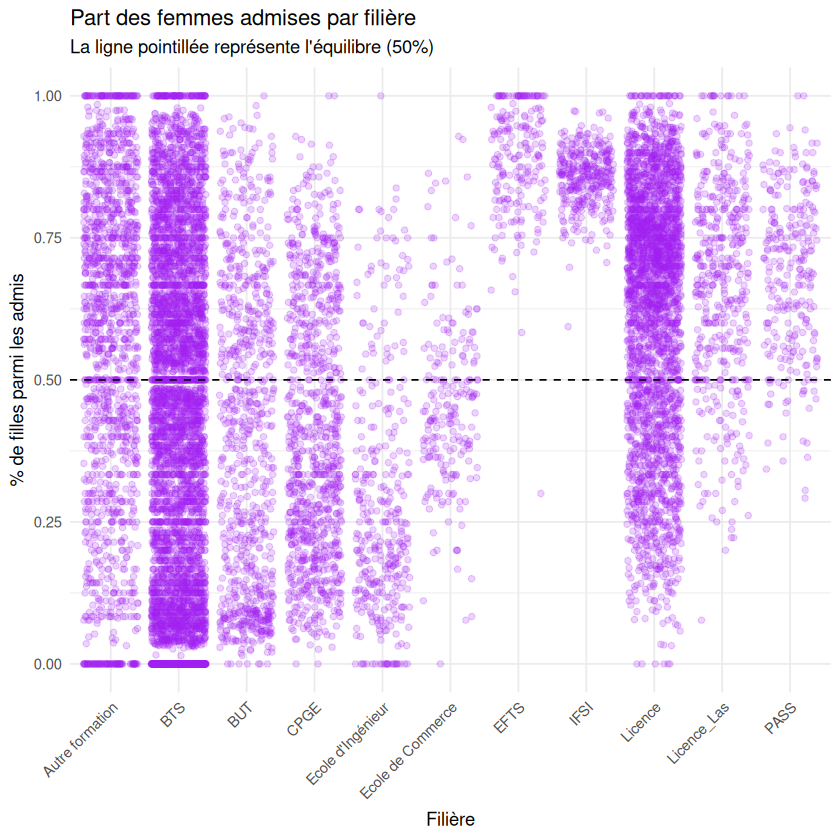

In [17]:
#Mixité par domaine
data_genre <- data_features_core %>%
  filter(log_admis > 2) # On filtre les petites formations pour la lisibilité

ggplot(data_genre, aes(x = Filière.de.formation.très.agrégée, y = pct_filles_admises)) +
  geom_jitter(alpha = 0.2, color = "purple") + 
  # CORRECTION ICI : yintercept au lieu de y0
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "black") + 
  labs(
    title = "Part des femmes admises par filière",
    subtitle = "La ligne pointillée représente l'équilibre (50%)",
    x = "Filière",
    y = "% de filles parmi les admis"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [18]:
dim(data_features_core)

[1] 14252    31

## ACM (Analyse des Correspondances Multiples)

L'ACM est l'équivalent de l'ACP pour les variables qualitatives. Ici, on repart du vecteur `var_quali` créé plus haut pour garder seulement les variables qualitatives, puis on résume les liaisons entre modalités sur quelques axes.

In [20]:
library(ca)
library(dplyr)
library(tidyr)

# On utilise directement le vecteur var_quali créé plus haut
data_mca <- data_features_core %>%
  select(all_of(var_quali)) %>%
  drop_na()



In [ ]:
# ACM simple sur les variables qualitatives
res_mca <- mjca(data_mca)


In [ ]:

# Résumé rapide des premiers axes
summary(res_mca)



In [ ]:
# Carte des modalités sur les deux premiers axes
plot(res_mca)



Principal inertias (eigenvalues):

 dim    value      %   cum%   scree plot               
 1      0.114912  59.5  59.5  *********************    
 2      0.017064   8.8  68.4  ***                      
 3      0.002684   1.4  69.8                           
 4      0.000850   0.4  70.2                           
 5      0.000602   0.3  70.5                           
 6      0.000324   0.2  70.7                           
 7      0.000247   0.1  70.8                           
 8      0.000165   0.1  70.9                           
 9      0.000119   0.1  70.9                           
 10     3.7e-050   0.0  71.0                           
 11     1e-06000   0.0  71.0                           
 12     00000000   0.0  71.0                           
 13     00000000   0.0  71.0                           
 14     00000000   0.0  71.0                           
 15     00000000   0.0  71.0                           
        -------- -----                                 
 Total: 0.19

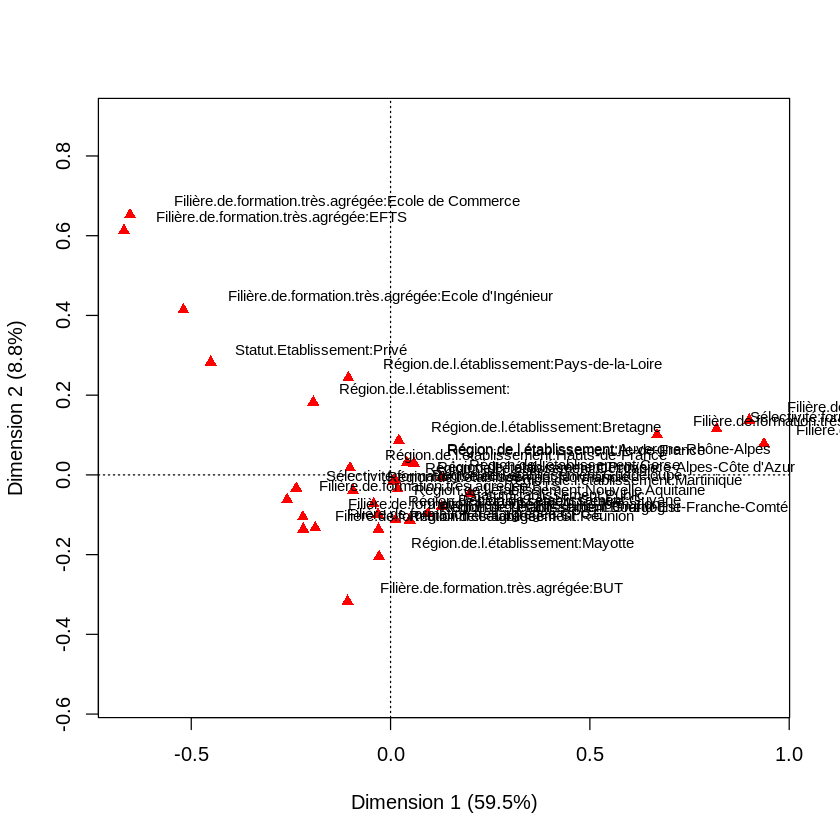

In [ ]:
# on va le faire seulement avec qq variable pour que ca ne prenne pâs trop de temps. sinon, l'acm dure méa longtemps !

vars_mca <- c(
  "Sélectivité",
  "Statut.Etablissement",
  "Région.de.l.établissement",
  "Filière.de.formation.très.agrégée"
)

data_mca <- data_features_core %>%
  select(all_of(vars_mca)) %>%
  drop_na()

res_mca <- mjca(data_mca)
summary(res_mca)
plot(res_mca)


In [ ]:
# 1. Fréquences simples des modalités les plus présentes
vars_mca <- c(
  "Sélectivité",
  "Statut.Etablissement",
  "Filière.de.formation.très.agrégée",
  "Région.de.l.établissement"
)

lapply(data_features_core[vars_mca], function(x) {
  sort(table(x), decreasing = TRUE)
})


$Sélectivité
x
    formation sélective formation non sélective 
                  11056                    3196 

$Statut.Etablissement
x
Public  Privé 
 11108   3144 

$Filière.de.formation.très.agrégée
x
              BTS           Licence   Autre formation              CPGE 
             5351              3052              1815               986 
              BUT Ecole d'Ingénieur       Licence_Las              IFSI 
              820               585               513               344 
             PASS Ecole de Commerce              EFTS 
              287               256               243 

$Région.de.l.établissement
x
             Ile-de-France       Auvergne-Rhône-Alpes 
                      2691                       1730 
           Hauts-de-France                  Occitanie 
                      1272                       1218 
        Nouvelle Aquitaine                  Grand-Est 
                      1162                       1150 
Provence-Alpes-Côte d'Azur      

On commence par regarder le résumé pour voir ce que portent les premiers axes. Puis on lit la carte : deux modalités proches ont tendance à apparaître ensemble, alors que des modalités opposées s'éloignent sur les axes.

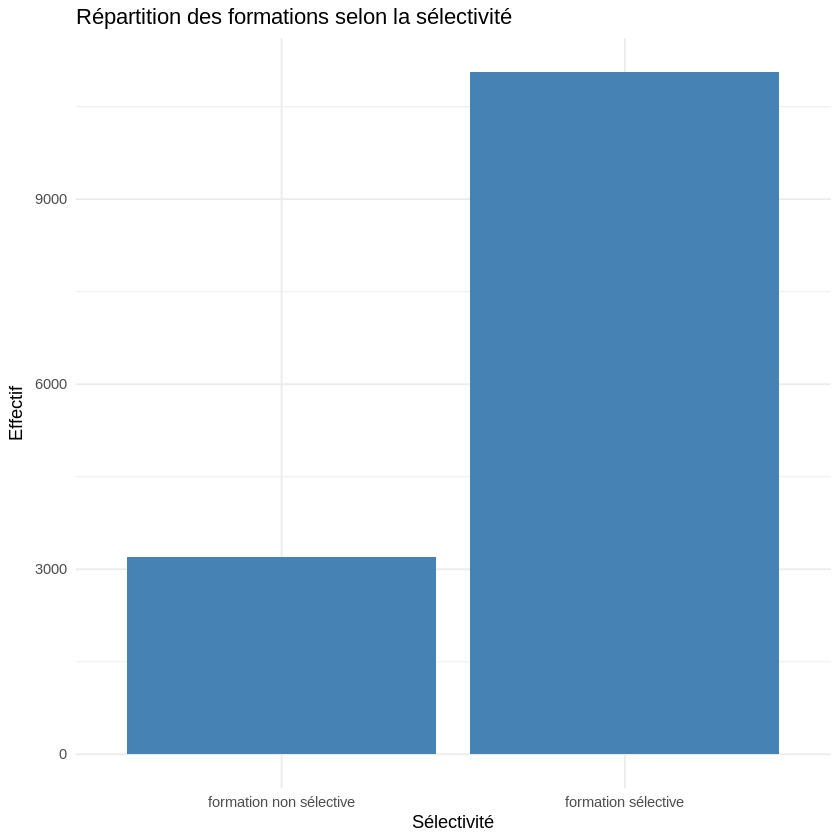

In [ ]:
# 1. Effectifs par sélectivité
library(ggplot2)

ggplot(data_features_core, aes(x = Sélectivité)) +
  geom_bar(fill = "steelblue") +
  labs(
    title = "Répartition des formations selon la sélectivité",
    x = "Sélectivité",
    y = "Effectif"
  ) +
  theme_minimal()

# Interprétation attendue :
# On repère d'abord quelle catégorie de sélectivité est la plus fréquente.
# Cela donne le contexte général avant de croiser avec d'autres variables.



Principal inertias (eigenvalues):

 dim    value      %   cum%   scree plot               
 1      0.114912  59.5  59.5  *********************    
 2      0.017064   8.8  68.4  ***                      
 3      0.002684   1.4  69.8                           
 4      0.000850   0.4  70.2                           
 5      0.000602   0.3  70.5                           
 6      0.000324   0.2  70.7                           
 7      0.000247   0.1  70.8                           
 8      0.000165   0.1  70.9                           
 9      0.000119   0.1  70.9                           
 10     3.7e-050   0.0  71.0                           
 11     1e-06000   0.0  71.0                           
 12     00000000   0.0  71.0                           
 13     00000000   0.0  71.0                           
 14     00000000   0.0  71.0                           
        -------- -----                                 
 Total: 0.193058                                       


Columns:
 

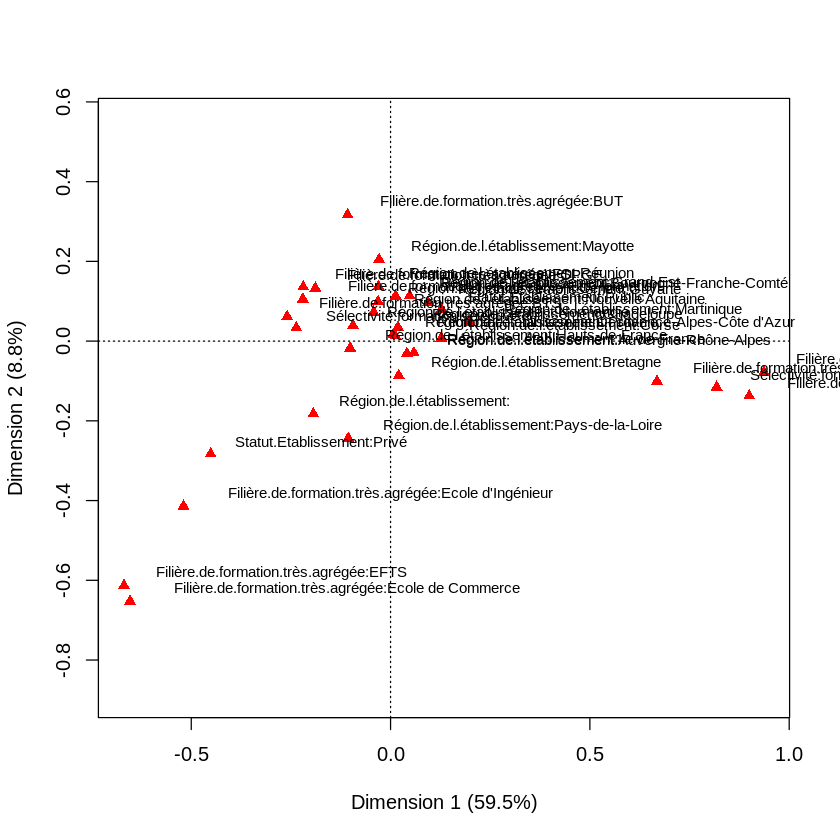

In [ ]:
# 2. ACM plus lisible sur un sous-ensemble de var qualit, on regarde le pouds des dim
library(ca)
library(dplyr)
library(tidyr)

data_mca_simple <- data_features_core %>%
  select(all_of(vars_mca)) %>%
  drop_na()

res_mca_simple <- mjca(data_mca_simple)

summary(res_mca_simple)
plot(res_mca_simple)


In [ ]:
# 3. Tableau croisé : sélectivité x filière, on regarde les liens entre les deux
tab_sel_filiere <- table(
  data_features_core$Sélectivité,
  data_features_core$Filière.de.formation.très.agrégée
)

tab_sel_filiere
prop.table(tab_sel_filiere, margin = 1)
chisq.test(tab_sel_filiere)


                         
                          Autre formation  BTS  BUT CPGE Ecole d'Ingénieur
  formation non sélective               0    0    0    0                 0
  formation sélective                1815 5351  820  986               585
                         
                          Ecole de Commerce EFTS IFSI Licence Licence_Las PASS
  formation non sélective                 0    0    0    2405         504  287
  formation sélective                   256  243  344     647           9    0

                         
                          Autre formation          BTS          BUT
  formation non sélective    0.0000000000 0.0000000000 0.0000000000
  formation sélective        0.1641642547 0.4839905933 0.0741678726
                         
                                  CPGE Ecole d'Ingénieur Ecole de Commerce
  formation non sélective 0.0000000000      0.0000000000      0.0000000000
  formation sélective     0.0891823444      0.0529124457      0.0231548480
                         
                                  EFTS         IFSI      Licence  Licence_Las
  formation non sélective 0.0000000000 0.0000000000 0.7525031289 0.1576971214
  formation sélective     0.0219790159 0.0311143271 0.0585202605 0.0008140376
                         
                                  PASS
  formation non sélective 0.0897997497
  formation sélective     0.0000000000


	Pearson's Chi-squared test

data:  tab_sel_filiere
X-squared = 11270, df = 10, p-value < 2.2e-16


In [ ]:
# 4. Tableau croisé : statut public/privé x filière, pareil aev differentes variables
tab_statut_filiere <- table(
  data_features_core$Statut.Etablissement,
  data_features_core$Filière.de.formation.très.agrégée
)

tab_statut_filiere
prop.table(tab_statut_filiere, margin = 1)
chisq.test(tab_statut_filiere)


        
         Autre formation  BTS  BUT CPGE Ecole d'Ingénieur Ecole de Commerce
  Privé              368 1378    1  156               412               250
  Public            1447 3973  819  830               173                 6
        
         EFTS IFSI Licence Licence_Las PASS
  Privé   241   66     259          13    0
  Public    2  278    2793         500  287

        
         Autre formation          BTS          BUT         CPGE
  Privé     0.1170483461 0.4382951654 0.0003180662 0.0496183206
  Public    0.1302664746 0.3576701476 0.0737306446 0.0747209219
        
         Ecole d'Ingénieur Ecole de Commerce         EFTS         IFSI
  Privé       0.1310432570      0.0795165394 0.0766539440 0.0209923664
  Public      0.0155743608      0.0005401512 0.0001800504 0.0250270076
        
              Licence  Licence_Las         PASS
  Privé  0.0823791349 0.0041348601 0.0000000000
  Public 0.2514404033 0.0450126035 0.0258372344


	Pearson's Chi-squared test

data:  tab_statut_filiere
X-squared = 3308.7, df = 10, p-value < 2.2e-16


In [ ]:
# 5. un autre Tableau croisé : sélectivité x statut
tab_sel_statut <- table(
  data_features_core$Sélectivité,
  data_features_core$Statut.Etablissement
)

tab_sel_statut
prop.table(tab_sel_statut, margin = 1)
chisq.test(tab_sel_statut)


                         
                          Privé Public
  formation non sélective   161   3035
  formation sélective      2983   8073

                         
                               Privé     Public
  formation non sélective 0.05037547 0.94962453
  formation sélective     0.26980825 0.73019175


	Pearson's Chi-squared test with Yates' continuity correction

data:  tab_sel_statut
X-squared = 693.05, df = 1, p-value < 2.2e-16


In [ ]:
# 6. Résidus standardisés pour repérer les associations fortes
test_sel_filiere <- chisq.test(tab_sel_filiere)

round(test_sel_filiere$stdres, 2)


                         
                          Autre formation    BTS    BUT   CPGE
  formation non sélective          -24.52 -49.77 -15.86 -17.50
  formation sélective               24.52  49.77  15.86  17.50
                         
                          Ecole d'Ingénieur Ecole de Commerce   EFTS   IFSI
  formation non sélective            -13.28             -8.68  -8.45 -10.09
  formation sélective                 13.28              8.68   8.45  10.09
                         
                          Licence Licence_Las   PASS
  formation non sélective   84.23       41.94  31.83
  formation sélective      -84.23      -41.94 -31.83

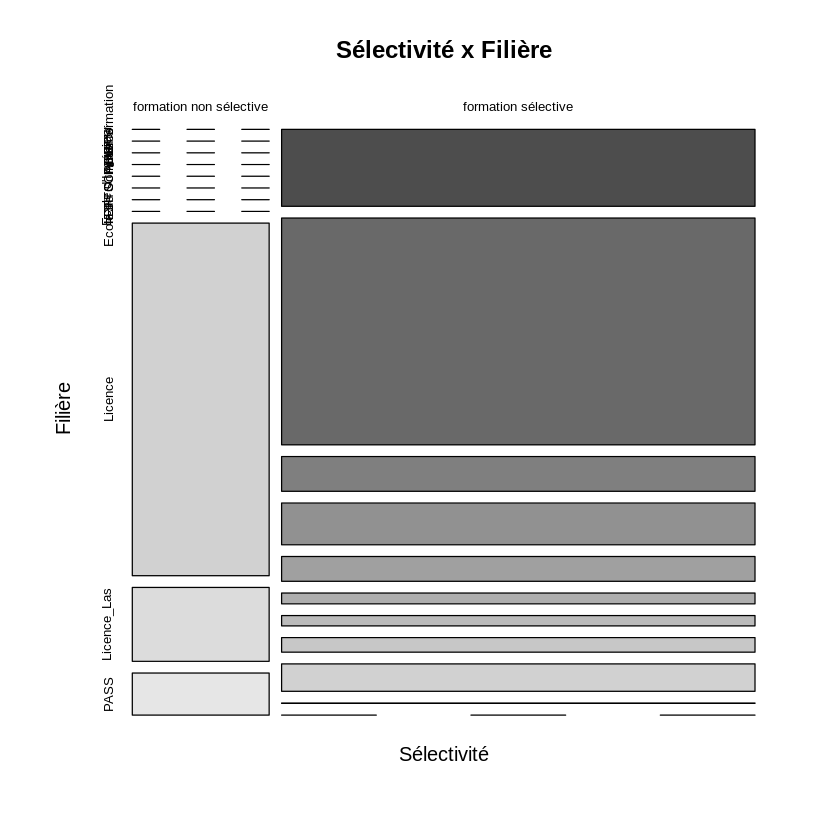

In [ ]:
# 7. Même idée avec un affichage plus visuel
mosaicplot(tab_sel_filiere, color = TRUE,
           main = "Sélectivité x Filière",
           xlab = "Sélectivité", ylab = "Filière")


In [ ]:
# 8. Régions les plus représentées selon la sélectivité
tab_sel_region <- table(
  data_features_core$Sélectivité,
  data_features_core$Région.de.l.établissement
)

round(prop.table(tab_sel_region, margin = 1), 3)
chisq.test(tab_sel_region)


                         
                                Auvergne-Rhône-Alpes Bourgogne-Franche-Comté
  formation non sélective 0.005                0.132                   0.040
  formation sélective     0.007                0.118                   0.041
                         
                          Bretagne Centre Corse Grand-Est Guadeloupe Guyane
  formation non sélective    0.061  0.029 0.007     0.082      0.010  0.006
  formation sélective        0.051  0.033 0.005     0.080      0.009  0.005
                         
                          Hauts-de-France Ile-de-France Martinique Mayotte
  formation non sélective           0.076         0.191      0.012   0.003
  formation sélective               0.093         0.188      0.008   0.003
                         
                          Normandie Nouvelle Aquitaine Occitanie
  formation non sélective     0.038              0.071     0.089
  formation sélective         0.046              0.085     0.085
                 


	Pearson's Chi-squared test

data:  tab_sel_region
X-squared = 39.313, df = 18, p-value = 0.002586


In [ ]:
# 9. Pour ne garder que les associations les plus marquées
as.data.frame(as.table(round(test_sel_filiere$stdres, 2))) %>%
  arrange(desc(abs(Freq))) %>%
  head(15)


,Var1,Var2,Freq
,<fct>,<fct>,<dbl>
1,formation non sélective,Licence,84.23
2,formation sélective,Licence,-84.23
3,formation non sélective,BTS,-49.77
4,formation sélective,BTS,49.77
5,formation non sélective,Licence_Las,41.94
6,formation sélective,Licence_Las,-41.94
7,formation non sélective,PASS,31.83
8,formation sélective,PASS,-31.83
9,formation non sélective,Autre formation,-24.52


In [ ]:
# 10. Petite synthèse descriptive utile avant interprétation
data_features_core %>%
  count(Sélectivité, Filière.de.formation.très.agrégée, sort = TRUE) %>%
  group_by(Sélectivité) %>%
  slice_head(n = 10)


Sélectivité,Filière.de.formation.très.agrégée,n
<fct>,<fct>,<int>
formation non sélective,Licence,2405
formation non sélective,Licence_Las,504
formation non sélective,PASS,287
formation sélective,BTS,5351
formation sélective,Autre formation,1815
formation sélective,CPGE,986
formation sélective,BUT,820
formation sélective,Licence,647
formation sélective,Ecole d'Ingénieur,585


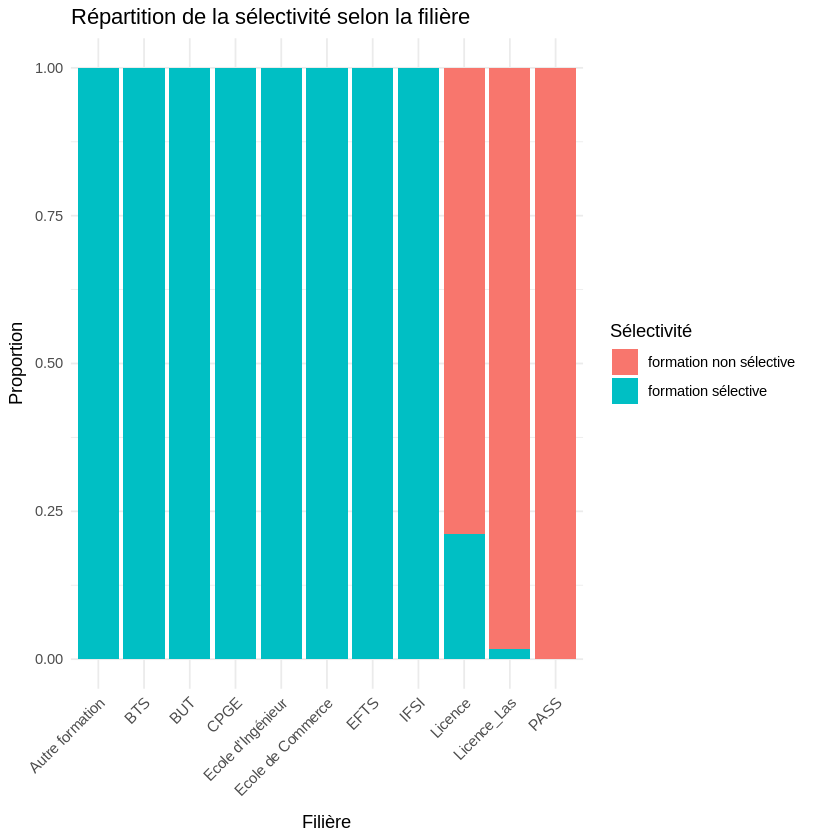

In [ ]:
# 2. Filières selon la sélectivité
ggplot(data_features_core, aes(x = Filière.de.formation.très.agrégée, fill = Sélectivité)) +
  geom_bar(position = "fill") +
  labs(
    title = "Répartition de la sélectivité selon la filière",
    x = "Filière",
    y = "Proportion"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Interprétation attendue :
# On compare la composition de chaque filière.
# Si certaines filières ont une forte part de formations sélectives, cela suggère un lien entre filière et sélectivité.


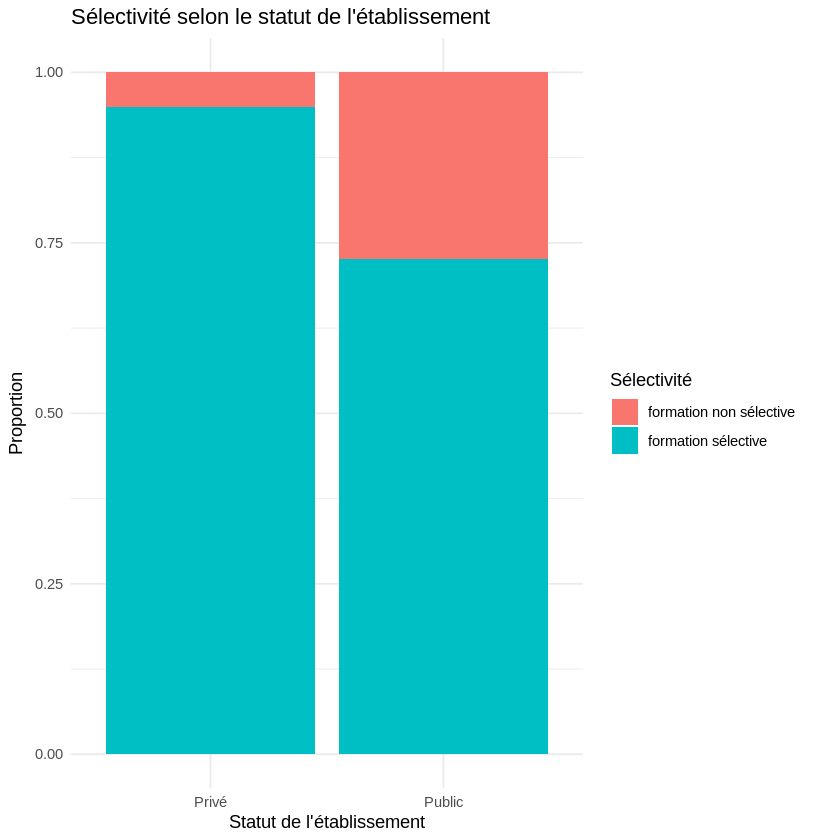

In [ ]:
# 3. Statut public/privé selon la sélectivité
ggplot(data_features_core, aes(x = Statut.Etablissement, fill = Sélectivité)) +
  geom_bar(position = "fill") +
  labs(
    title = "Sélectivité selon le statut de l'établissement",
    x = "Statut de l'établissement",
    y = "Proportion"
  ) +
  theme_minimal()

# Interprétation attendue :
# On regarde si la part de formations sélectives est la même dans le public et dans le privé.
# Un écart visible suggère une association entre statut et sélectivité.


In [ ]:
# 4. Test du khi-deux : sélectivité x filière
tab_sel_filiere <- table(
  data_features_core$Sélectivité,
  data_features_core$Filière.de.formation.très.agrégée
)



test_sel_filiere <- chisq.test(tab_sel_filiere)

tab_sel_filiere
round(prop.table(tab_sel_filiere, margin = 1), 3)
test_sel_filiere

# Interprétation attendue :
# Si la p-value est petite, on rejette l'indépendance.
# Cela signifie que la sélectivité dépend au moins en partie du type de filière.



                         
                          Autre formation  BTS  BUT CPGE Ecole d'Ingénieur
  formation non sélective               0    0    0    0                 0
  formation sélective                1815 5351  820  986               585
                         
                          Ecole de Commerce EFTS IFSI Licence Licence_Las PASS
  formation non sélective                 0    0    0    2405         504  287
  formation sélective                   256  243  344     647           9    0

                         
                          Autre formation   BTS   BUT  CPGE Ecole d'Ingénieur
  formation non sélective           0.000 0.000 0.000 0.000             0.000
  formation sélective               0.164 0.484 0.074 0.089             0.053
                         
                          Ecole de Commerce  EFTS  IFSI Licence Licence_Las
  formation non sélective             0.000 0.000 0.000   0.753       0.158
  formation sélective                 0.023 0.022 0.031   0.059       0.001
                         
                           PASS
  formation non sélective 0.090
  formation sélective     0.000


	Pearson's Chi-squared test

data:  tab_sel_filiere
X-squared = 11270, df = 10, p-value < 2.2e-16
